# Yelp Dataset Statistics — Experiments Section

Generates all dataset numbers and tables needed for the **Experiments** section of the paper.

- **Raw source**: `Datasets/yelp_dataset/` (Yelp Academic Dataset)
- **Preprocessed**: `Datasets/yelp-merchant/` (filtered, indexed, feature-extracted)


In [1]:
import json, pickle, os, subprocess
import numpy as np
import pandas as pd
import scipy.sparse as sp
from collections import Counter
from datetime import datetime

RAW_DIR  = os.path.join(os.path.dirname(os.getcwd()), 'gg', 'Datasets', 'yelp_dataset')
PROC_DIR = os.path.join(os.path.dirname(os.getcwd()), 'gg', 'Datasets', 'yelp-merchant')

# Adjust if running from repo root
if not os.path.isdir(RAW_DIR):
    RAW_DIR  = 'Datasets/yelp_dataset'
    PROC_DIR = 'Datasets/yelp-merchant'

print('Raw  dir:', RAW_DIR)
print('Proc dir:', PROC_DIR)


Raw  dir: /Users/altanshagai/Desktop/lesson/paper/gg/Datasets/yelp_dataset
Proc dir: /Users/altanshagai/Desktop/lesson/paper/gg/Datasets/yelp-merchant


## 1. Raw Yelp Academic Dataset

Count total records in each source file and display key schema fields.

In [2]:
def count_lines(path):
    """Count newline-terminated JSON records quickly."""
    result = subprocess.run(['wc', '-l', path], capture_output=True, text=True)
    return int(result.stdout.strip().split()[0])

raw_files = {
    'Users':      'yelp_academic_dataset_user.json',
    'Businesses': 'yelp_academic_dataset_business.json',
    'Reviews':    'yelp_academic_dataset_review.json',
    'Tips':       'yelp_academic_dataset_tip.json',
    'Check-ins':  'yelp_academic_dataset_checkin.json',
}

raw_schema = {
    'Users':      'user_id, name, review_count, yelping_since, useful, funny, cool, elite, friends, fans, average_stars, compliment_*',
    'Businesses': 'business_id, name, address, city, state, postal_code, latitude, longitude, stars, review_count, is_open, attributes, categories, hours',
    'Reviews':    'review_id, user_id, business_id, stars, useful, funny, cool, text, date',
    'Tips':       'user_id, business_id, text, date, compliment_count',
    'Check-ins':  'business_id, date (comma-sep timestamps)',
}

rows = []
for entity, fname in raw_files.items():
    path = os.path.join(RAW_DIR, fname)
    n = count_lines(path)
    rows.append({'Entity': entity, 'Records': f'{n:,}', 'Key Fields': raw_schema[entity]})

raw_df = pd.DataFrame(rows)
print("=== Raw Yelp Academic Dataset ===")
print(raw_df.to_string(index=False))


=== Raw Yelp Academic Dataset ===
    Entity   Records                                                                                                                             Key Fields
     Users 1,987,897                     user_id, name, review_count, yelping_since, useful, funny, cool, elite, friends, fans, average_stars, compliment_*
Businesses   150,346 business_id, name, address, city, state, postal_code, latitude, longitude, stars, review_count, is_open, attributes, categories, hours
   Reviews 6,990,280                                                                review_id, user_id, business_id, stars, useful, funny, cool, text, date
      Tips   908,915                                                                                     user_id, business_id, text, date, compliment_count
 Check-ins   131,930                                                                                               business_id, date (comma-sep timestamps)


## 2. Filtered / Preprocessed Dataset (yelp-merchant)

After filtering (min-interaction threshold, train/val/test split), the dataset is reduced to the numbers used in our model.

In [3]:
# ── Load preprocessed artefacts ──────────────────────────────────────────────
with open(os.path.join(PROC_DIR, 'user2id.pkl'),     'rb') as f: user2id     = pickle.load(f)
with open(os.path.join(PROC_DIR, 'merchant2id.pkl'), 'rb') as f: merchant2id = pickle.load(f)
with open(os.path.join(PROC_DIR, 'trn_mat_time'),    'rb') as f: trn_data    = pickle.load(f)
with open(os.path.join(PROC_DIR, 'tst_int'),         'rb') as f: tst_int     = pickle.load(f)
with open(os.path.join(PROC_DIR, 'sequence'),        'rb') as f: sequences   = pickle.load(f)
with open(os.path.join(PROC_DIR, 'edge_weights.pkl'),'rb') as f: edge_weights= pickle.load(f)

user_feats     = np.load(os.path.join(PROC_DIR, 'user_features.npy'))
merchant_feats = np.load(os.path.join(PROC_DIR, 'merchant_features.npy'))

# ── Basic counts ──────────────────────────────────────────────────────────────
overall_mat = trn_data[0]   # full training interaction matrix
sub_mats    = trn_data[1]   # list of T temporal sub-graphs

num_users     = len(user2id)
num_merchants = len(merchant2id)
num_train     = overall_mat.nnz
num_test      = len(tst_int)
T             = len(sub_mats)

# Sequence stats
seq_lens = [len(s) for s in sequences]

# Edge weight (star rating) stats
ew_vals = list(edge_weights.values())

print(f"Users           : {num_users:>10,}")
print(f"Merchants       : {num_merchants:>10,}")
print(f"Train interactions: {num_train:>8,}")
print(f"Test users      : {num_test:>10,}")
print(f"Temporal graphs : {T:>10}")
print(f"Seq avg length  : {np.mean(seq_lens):>10.2f}")
print(f"Seq max length  : {max(seq_lens):>10,}")
print(f"Edge weight mean: {np.mean(ew_vals):>10.3f}  (star ratings 1-5)")
print(f"Edge weight std : {np.std(ew_vals):>10.3f}")


Users           :    268,653
Merchants       :    109,325
Train interactions: 3,980,492
Test users      :    268,653
Temporal graphs :          5
Seq avg length  :      15.52
Seq max length  :      2,921
Edge weight mean:      3.839  (star ratings 1-5)
Edge weight std :      1.325


## 3. Temporal Sub-graph Breakdown

The full interaction history is split into **T = 5** time-interval sub-graphs (most recent = G5).

In [4]:
subgraph_rows = []
for i, sm in enumerate(sub_mats):
    density = sm.nnz / (sm.shape[0] * sm.shape[1]) * 100
    subgraph_rows.append({
        'Sub-graph': f'G{i+1}',
        'Interactions': f'{sm.nnz:,}',
        'Density (%)': f'{density:.5f}',
    })

sg_df = pd.DataFrame(subgraph_rows)
sg_df.loc[len(sg_df)] = ['Total (train)', f'{num_train:,}',
                          f'{num_train/(overall_mat.shape[0]*overall_mat.shape[1])*100:.5f}']
print(sg_df.to_string(index=False))


    Sub-graph Interactions Density (%)
           G1       32,561     0.00011
           G2      330,450     0.00113
           G3      914,624     0.00311
           G4    1,540,756     0.00525
           G5    1,213,684     0.00413
Total (train)    3,980,492     0.01355


## 4. Node Features

### 4a. User Features (4-dimensional)
Derived from the review history of each user.

### 4b. Merchant Features (6-dimensional)
Derived from the Yelp business JSON.

In [5]:
user_feat_meta = [
    ('review_count',     'Total number of reviews written by the user',    'integer'),
    ('avg_stars',        'Average star rating given across all reviews',    'float [1,5]'),
    ('review_span_days', 'Days between first and most recent review',       'integer'),
    ('unique_biz',       'Number of distinct businesses reviewed',          'integer'),
]

merch_feat_meta = [
    ('stars',            'Average Yelp star rating of the business',        'float [1,5]'),
    ('log_review_count', 'log(1 + total review count)',                     'float ≥ 0'),
    ('num_categories',   'Number of category tags on the business',         'integer'),
    ('is_open',          'Whether the business is currently open',          'binary {0,1}'),
    ('is_top_city',      'Business city is in the top-50 cities by count',  'binary {0,1}'),
    ('is_top_category',  'Primary category is in the top-30 categories',    'binary {0,1}'),
]

# ── User feature table ────────────────────────────────────────────────────────
uf_stats = []
col_names = ['review_count','avg_stars','review_span_days','unique_biz']
for i, (name, desc, dtype) in enumerate(user_feat_meta):
    col = user_feats[:, i]
    uf_stats.append({
        'Feature': name,
        'Description': desc,
        'Type': dtype,
        'Mean (raw*)': '—',
        'Std (raw*)': '—',
    })

uf_df = pd.DataFrame(uf_stats)
print("=== User Features (4-dim) ===")
print(uf_df.to_string(index=False))

# ── Merchant feature table ────────────────────────────────────────────────────
mf_stats = []
for i, (name, desc, dtype) in enumerate(merch_feat_meta):
    mf_stats.append({
        'Feature': name,
        'Description': desc,
        'Type': dtype,
    })

mf_df = pd.DataFrame(mf_stats)
print("\n=== Merchant Features (6-dim) ===")
print(mf_df.to_string(index=False))


=== User Features (4-dim) ===
         Feature                                  Description        Type Mean (raw*) Std (raw*)
    review_count  Total number of reviews written by the user     integer           —          —
       avg_stars Average star rating given across all reviews float [1,5]           —          —
review_span_days    Days between first and most recent review     integer           —          —
      unique_biz       Number of distinct businesses reviewed     integer           —          —

=== Merchant Features (6-dim) ===
         Feature                                    Description         Type
           stars       Average Yelp star rating of the business  float [1,5]
log_review_count                    log(1 + total review count)    float ≥ 0
  num_categories        Number of category tags on the business      integer
         is_open         Whether the business is currently open binary {0,1}
     is_top_city Business city is in the top-50 cities by count b

## 5. Edge Features

Each training interaction (user → merchant) carries a **star rating** as its edge weight, used instead of binary adjacency in the `selfGNN-Feature` variant.

=== Edge Weight Distribution (star ratings) ===
Total edges : 3,999,575
Mean rating : 3.839
Std  rating : 1.325

Star Rating     Count Share (%)
        1 ★   401,721      10.0
        2 ★   322,183       8.1
        3 ★   505,727      12.6
        4 ★ 1,058,742      26.5
        5 ★ 1,711,202      42.8


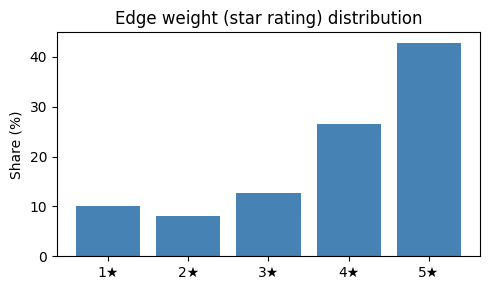

In [6]:
import matplotlib.pyplot as plt

ew_arr = np.array(ew_vals)
star_counts = Counter(ew_arr.astype(int))

edge_rows = []
for star in [1,2,3,4,5]:
    cnt = star_counts.get(star, 0)
    edge_rows.append({
        'Star Rating': f'{star} ★',
        'Count': f'{cnt:,}',
        'Share (%)': f'{cnt/len(ew_arr)*100:.1f}',
    })
edge_df = pd.DataFrame(edge_rows)
print("=== Edge Weight Distribution (star ratings) ===")
print(f"Total edges : {len(ew_arr):,}")
print(f"Mean rating : {ew_arr.mean():.3f}")
print(f"Std  rating : {ew_arr.std():.3f}\n")
print(edge_df.to_string(index=False))

# quick bar chart
fig, ax = plt.subplots(figsize=(5,3))
ax.bar([str(s)+'★' for s in [1,2,3,4,5]],
       [star_counts.get(s,0)/len(ew_arr)*100 for s in [1,2,3,4,5]],
       color='steelblue')
ax.set_ylabel('Share (%)')
ax.set_title('Edge weight (star rating) distribution')
plt.tight_layout()
plt.savefig('Datasets/yelp-merchant/edge_weight_dist.png', dpi=150)
plt.show()


## 6. Summary Table — paper-ready

Single consolidated table for the **Experiments / Dataset** paragraph.

In [7]:
density = num_train / (num_users * num_merchants) * 100

summary = pd.DataFrame([
    ('Dataset',                'Yelp Academic Dataset (merchant subset)'),
    ('Users  |U|',             f'{num_users:,}'),
    ('Merchants  |M|',         f'{num_merchants:,}'),
    ('Training interactions',  f'{num_train:,}'),
    ('Test users',             f'{num_test:,}'),
    ('Density',                f'{density:.4f}%'),
    ('Temporal sub-graphs T',  str(T)),
    ('Avg sequence length',    f'{np.mean(seq_lens):.2f}'),
    ('Max sequence length',    f'{max(seq_lens):,}'),
    ('Edge feature',           'Star rating ∈ {1,2,3,4,5}  (mean 3.84)'),
    ('User node features',     '4-dim: review_count, avg_stars, span_days, unique_biz'),
    ('Merchant node features', '6-dim: stars, log_review_cnt, num_cats, is_open, top_city, top_cat'),
], columns=['Statistic', 'Value'])

print(summary.to_string(index=False))


             Statistic                                                              Value
               Dataset                            Yelp Academic Dataset (merchant subset)
            Users  |U|                                                            268,653
        Merchants  |M|                                                            109,325
 Training interactions                                                          3,980,492
            Test users                                                            268,653
               Density                                                            0.0136%
 Temporal sub-graphs T                                                                  5
   Avg sequence length                                                              15.52
   Max sequence length                                                              2,921
          Edge feature                             Star rating ∈ {1,2,3,4,5}  (mean 3.84)
    User n

## 7. LaTeX Tables

Copy-paste ready tables for the paper.

In [8]:
density_val = num_train / (num_users * num_merchants) * 100

latex_dataset = r"""\begin{table}[t]
\centering
\caption{Statistics of the Yelp-Merchant dataset used for evaluation.}
\label{tab:dataset}
\begin{tabular}{lr}
\hline
\textbf{Statistic} & \textbf{Value} \\
\hline
Users $|U|$                        & """ + f"{num_users:,}" + r""" \\
Merchants $|M|$                    & """ + f"{num_merchants:,}" + r""" \\
Training interactions              & """ + f"{num_train:,}" + r""" \\
Test users                         & """ + f"{num_test:,}" + r""" \\
Interaction density                & """ + f"{density_val:.4f}\\%" + r""" \\
Temporal sub-graphs ($T$)          & """ + str(T) + r""" \\
Avg.\ sequence length              & """ + f"{np.mean(seq_lens):.2f}" + r""" \\
Max.\ sequence length              & """ + f"{max(seq_lens):,}" + r""" \\
\hline
\end{tabular}
\end{table}"""

print(latex_dataset)


\begin{table}[t]
\centering
\caption{Statistics of the Yelp-Merchant dataset used for evaluation.}
\label{tab:dataset}
\begin{tabular}{lr}
\hline
\textbf{Statistic} & \textbf{Value} \\
\hline
Users $|U|$                        & 268,653 \\
Merchants $|M|$                    & 109,325 \\
Training interactions              & 3,980,492 \\
Test users                         & 268,653 \\
Interaction density                & 0.0136\% \\
Temporal sub-graphs ($T$)          & 5 \\
Avg.\ sequence length              & 15.52 \\
Max.\ sequence length              & 2,921 \\
\hline
\end{tabular}
\end{table}


In [9]:
latex_user_feats = r"""\begin{table}[t]
\centering
\caption{User node features (4-dimensional, z-score normalized).}
\label{tab:user_features}
\begin{tabular}{lll}
\hline
\textbf{Feature} & \textbf{Description} & \textbf{Type} \\
\hline
\texttt{review\_count}     & Total reviews written by the user          & Integer \\
\texttt{avg\_stars}        & Mean star rating given by the user         & Float $[1,5]$ \\
\texttt{span\_days}        & Days between first and last review         & Integer \\
\texttt{unique\_biz}       & Number of distinct businesses reviewed     & Integer \\
\hline
\end{tabular}
\end{table}"""

latex_merch_feats = r"""\begin{table}[t]
\centering
\caption{Merchant node features (6-dimensional, z-score normalized).}
\label{tab:merchant_features}
\begin{tabular}{lll}
\hline
\textbf{Feature} & \textbf{Description} & \textbf{Type} \\
\hline
\texttt{stars}             & Yelp average star rating                   & Float $[1,5]$ \\
\texttt{log\_review\_cnt}  & $\log(1 + \text{review count})$            & Float $\geq 0$ \\
\texttt{num\_categories}   & Number of category tags                    & Integer \\
\texttt{is\_open}          & Business currently open                    & Binary \\
\texttt{is\_top\_city}     & City in top-50 by business count           & Binary \\
\texttt{is\_top\_category} & Primary category in top-30                 & Binary \\
\hline
\end{tabular}
\end{table}"""

print(latex_user_feats)
print()
print(latex_merch_feats)


\begin{table}[t]
\centering
\caption{User node features (4-dimensional, z-score normalized).}
\label{tab:user_features}
\begin{tabular}{lll}
\hline
\textbf{Feature} & \textbf{Description} & \textbf{Type} \\
\hline
\texttt{review\_count}     & Total reviews written by the user          & Integer \\
\texttt{avg\_stars}        & Mean star rating given by the user         & Float $[1,5]$ \\
\texttt{span\_days}        & Days between first and last review         & Integer \\
\texttt{unique\_biz}       & Number of distinct businesses reviewed     & Integer \\
\hline
\end{tabular}
\end{table}

\begin{table}[t]
\centering
\caption{Merchant node features (6-dimensional, z-score normalized).}
\label{tab:merchant_features}
\begin{tabular}{lll}
\hline
\textbf{Feature} & \textbf{Description} & \textbf{Type} \\
\hline
\texttt{stars}             & Yelp average star rating                   & Float $[1,5]$ \\
\texttt{log\_review\_cnt}  & $\log(1 + \text{review count})$            & Float $\geq 0$ \\
\